In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [2]:
iz = 244
bs = 32

In [9]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "Dataset_Aug",
    shuffle = True,
    seed = 16,
    image_size = (iz, iz),
    batch_size = bs
)

Found 3055 files belonging to 2 classes.


In [10]:
class_names = dataset.class_names
print (class_names)          #class names are nothing but the files names i.e. it divided the class accourding the files

class_number = 1 # for sigmoid in model 

['Not_OK', 'OK']


In [11]:
# Now to split dataset we can do it following way
# 80% for training
# 10% for validation
# 10% for testing
ts = int(len(dataset)*0.8)
vs = int(len(dataset)*0.1)
# print("Total lenght of dataset : ", len(dataset))
# print("80% for training : ", int(len(dataset)*0.8))
# print("10% for validation : ", int(len(dataset)*0.1))
# print("10% for testing : ", int(len(dataset) - (int(len(dataset)*0.8) + int(len(dataset)*0.1))))

In [12]:
# Dividing the dataset

training_ds = dataset.take(ts)              #arr[:84]
remaining_ds = dataset.skip(ts)             #arr[84:]
validation_ds = remaining_ds.take(vs)
testing_ds = dataset.skip(ts)

print("Lenght of training dataset : ", len(training_ds))
print("Lenght of validation dataset : ", len(validation_ds))
print("Lenght of testing dataset : ", len(testing_ds))

Lenght of training dataset :  76
Lenght of validation dataset :  9
Lenght of testing dataset :  20


In [13]:
from tensorflow.keras.applications import ResNet50

model = models.Sequential()
model.add(ResNet50(include_top=False, pooling='max', weights='imagenet', input_shape = (iz, iz, 3)))
model.add(Dense(class_number, activation='sigmoid'))
model.layers[0].trainable = False

In [14]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 2048)              23587712  
                                                                 
 dense (Dense)               (None, 1)                 2049      
                                                                 
Total params: 23,589,761
Trainable params: 2,049
Non-trainable params: 23,587,712
_________________________________________________________________


In [15]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [16]:
early = EarlyStopping(monitor = 'val_loss', patience=3)

In [17]:
history_1 = model.fit(training_ds, epochs=10, validation_data=validation_ds, callbacks=early)

Epoch 1/10
76/76 [==============================] - 82s 900ms/step - loss: 0.7455 - accuracy: 0.7784 - val_loss: 0.1536 - val_accuracy: 0.9444
Epoch 2/10
76/76 [==============================] - 75s 949ms/step - loss: 0.1243 - accuracy: 0.9511 - val_loss: 0.1301 - val_accuracy: 0.9444
Epoch 3/10
76/76 [==============================] - 74s 949ms/step - loss: 0.0801 - accuracy: 0.9708 - val_loss: 0.0531 - val_accuracy: 0.9792
Epoch 4/10
76/76 [==============================] - 75s 954ms/step - loss: 0.0490 - accuracy: 0.9856 - val_loss: 0.0470 - val_accuracy: 0.9826
Epoch 5/10
76/76 [==============================] - 76s 967ms/step - loss: 0.0340 - accuracy: 0.9914 - val_loss: 0.0638 - val_accuracy: 0.9653
Epoch 6/10
76/76 [==============================] - 77s 982ms/step - loss: 0.0284 - accuracy: 0.9947 - val_loss: 0.0481 - val_accuracy: 0.9792
Epoch 7/10
76/76 [==============================] - 76s 970ms/step - loss: 0.0226 - accuracy: 0.9951 - val_loss: 0.0230 - val_accuracy: 0.9931

In [18]:
scores_1 = model.evaluate(testing_ds)
scores_1

20/20 [==============================] - 38s 555ms/step - loss: 0.0281 - accuracy: 0.9904


[0.028149789199233055, 0.9903692007064819]

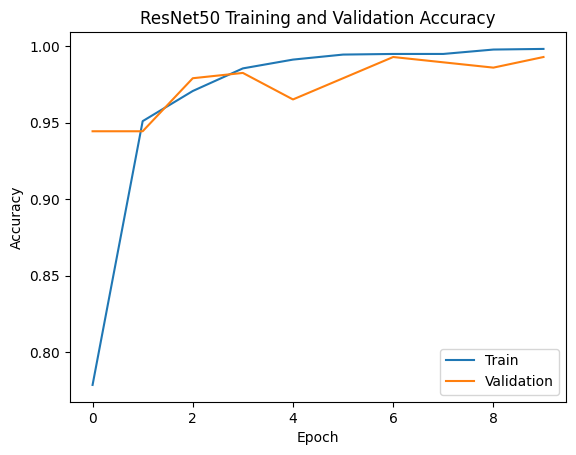

In [19]:
# Plot training and validation accuracy
plt.plot(history_1.history['accuracy'], label='Train')
plt.plot(history_1.history['val_accuracy'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('ResNet50 Training and Validation Accuracy')
plt.show()

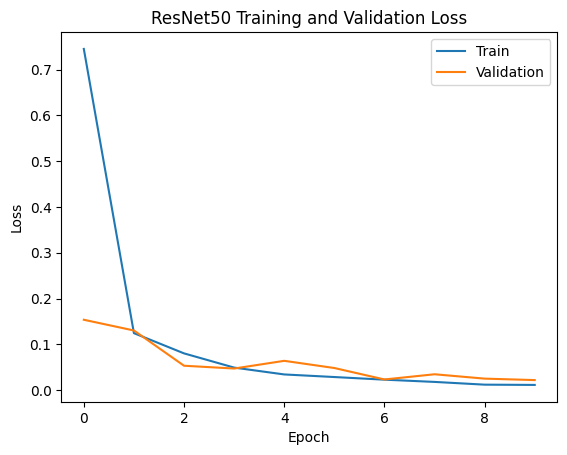

In [20]:
# Plot training and validation accuracy
plt.plot(history_1.history['loss'], label='Train')
plt.plot(history_1.history['val_loss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('ResNet50 Training and Validation Loss')
plt.show()

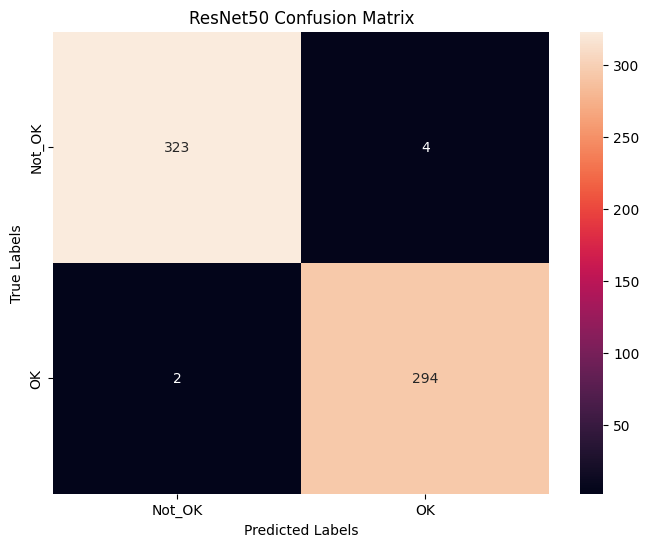

In [21]:
# Get the predicted labels for the test set
predicted_labels = []
true_labels = []

for images, labels in testing_ds:
    true_labels.extend(labels.numpy())
    predictions = model.predict(images, verbose=0)
    predicted_labels.extend((predictions > 0.5).astype(int).flatten())

# Create a confusion matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels)

# Plot the confusion matrix using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('ResNet50 Confusion Matrix')
plt.show()


In [22]:
model.save(f"Models/ResNet50_V2")

INFO:tensorflow:Assets written to: Models/ResNet50_V2\assets


INFO:tensorflow:Assets written to: Models/ResNet50_V2\assets


In [23]:
from tensorflow.keras.applications import VGG16

model = models.Sequential()
model.add(VGG16(include_top=False, pooling='max', weights='imagenet', input_shape = (iz, iz, 3)))
model.add(Dense(class_number, activation='sigmoid'))
model.layers[0].trainable = False

In [24]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 512)               14714688  
                                                                 
 dense_1 (Dense)             (None, 1)                 513       
                                                                 
Total params: 14,715,201
Trainable params: 513
Non-trainable params: 14,714,688
_________________________________________________________________


In [25]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [26]:
early = EarlyStopping(monitor = 'val_loss', patience=3)

In [27]:
history_2 = model.fit(training_ds, epochs=10, validation_data=validation_ds, callbacks=early)

Epoch 1/10


76/76 [==============================] - 120s 1s/step - loss: 3.5260 - accuracy: 0.6863 - val_loss: 0.7612 - val_accuracy: 0.8681
Epoch 2/10
76/76 [==============================] - 99s 1s/step - loss: 0.8412 - accuracy: 0.8980 - val_loss: 0.4669 - val_accuracy: 0.9167
Epoch 3/10
76/76 [==============================] - 99s 1s/step - loss: 0.4903 - accuracy: 0.9400 - val_loss: 0.3795 - val_accuracy: 0.9583
Epoch 4/10
76/76 [==============================] - 99s 1s/step - loss: 0.3903 - accuracy: 0.9507 - val_loss: 0.3888 - val_accuracy: 0.9549
Epoch 5/10
76/76 [==============================] - 56s 708ms/step - loss: 0.2951 - accuracy: 0.9597 - val_loss: 0.2997 - val_accuracy: 0.9583
Epoch 6/10
76/76 [==============================] - 56s 699ms/step - loss: 0.2183 - accuracy: 0.9671 - val_loss: 0.0637 - val_accuracy: 0.9757
Epoch 7/10
76/76 [==============================] - 55s 689ms/step - loss: 0.1658 - accuracy: 0.9733 - val_loss: 0.1086 - val_accuracy: 0.9722
Epoch 8/10
76/76 [===

In [28]:
scores_2 = model.evaluate(testing_ds)
scores_2

20/20 [==============================] - 34s 486ms/step - loss: 0.0583 - accuracy: 0.9839


[0.058343689888715744, 0.9839486479759216]

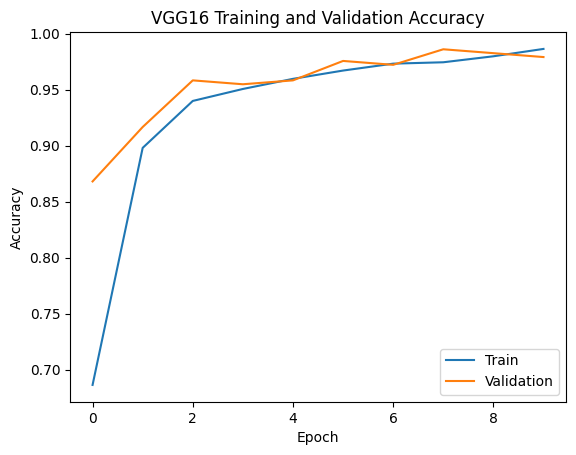

In [29]:
# Plot training and validation accuracy
plt.plot(history_2.history['accuracy'], label='Train')
plt.plot(history_2.history['val_accuracy'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('VGG16 Training and Validation Accuracy')
plt.show()

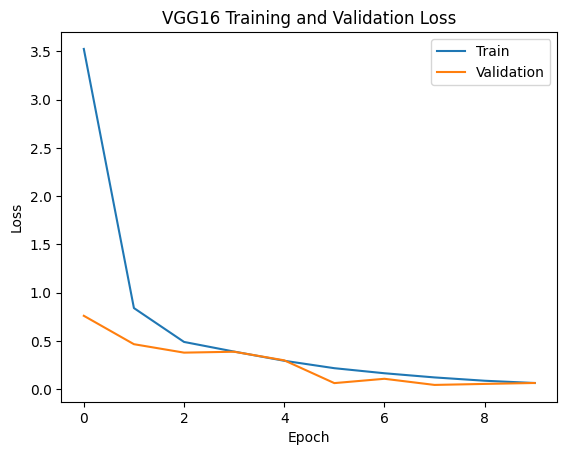

In [30]:
# Plot training and validation accuracy
plt.plot(history_2.history['loss'], label='Train')
plt.plot(history_2.history['val_loss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('VGG16 Training and Validation Loss')
plt.show()

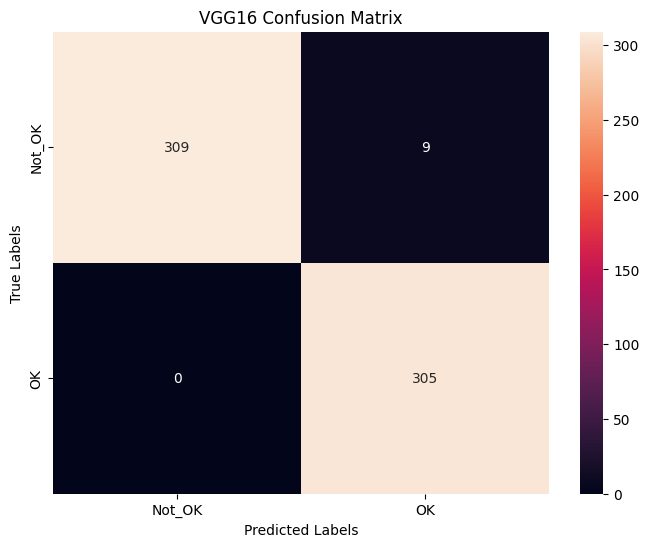

In [31]:
# Get the predicted labels for the test set
predicted_labels = []
true_labels = []

for images, labels in testing_ds:
    true_labels.extend(labels.numpy())
    predictions = model.predict(images, verbose=0)
    predicted_labels.extend((predictions > 0.5).astype(int).flatten())

# Create a confusion matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels)

# Plot the confusion matrix using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('VGG16 Confusion Matrix')
plt.show()


In [32]:
model.save(f"Models/VGG16_V2")

INFO:tensorflow:Assets written to: Models/VGG16_V2\assets


INFO:tensorflow:Assets written to: Models/VGG16_V2\assets


In [33]:
from tensorflow.keras.applications import EfficientNetV2B3

model = models.Sequential()
model.add(EfficientNetV2B3(include_top=False, pooling='max', weights='imagenet', input_shape = (iz, iz, 3)))
model.add(Dense(class_number, activation='sigmoid'))
model.layers[0].trainable = False

In [34]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetv2-b3 (Function  (None, 1536)             12930622  
 al)                                                             
                                                                 
 dense_2 (Dense)             (None, 1)                 1537      
                                                                 
Total params: 12,932,159
Trainable params: 1,537
Non-trainable params: 12,930,622
_________________________________________________________________


In [35]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [36]:
early = EarlyStopping(monitor = 'val_loss', patience=3)

In [37]:
history_3 = model.fit(training_ds, epochs=10, validation_data=validation_ds, callbacks=early)

Epoch 1/10


76/76 [==============================] - 62s 656ms/step - loss: 0.3892 - accuracy: 0.8314 - val_loss: 0.1257 - val_accuracy: 0.9688
Epoch 2/10
76/76 [==============================] - 53s 672ms/step - loss: 0.1522 - accuracy: 0.9465 - val_loss: 0.1138 - val_accuracy: 0.9826
Epoch 3/10
76/76 [==============================] - 52s 656ms/step - loss: 0.1086 - accuracy: 0.9655 - val_loss: 0.0732 - val_accuracy: 0.9861
Epoch 4/10
76/76 [==============================] - 52s 653ms/step - loss: 0.0855 - accuracy: 0.9778 - val_loss: 0.0568 - val_accuracy: 0.9896
Epoch 5/10
76/76 [==============================] - 52s 653ms/step - loss: 0.0718 - accuracy: 0.9786 - val_loss: 0.0624 - val_accuracy: 0.9861
Epoch 6/10
76/76 [==============================] - 53s 662ms/step - loss: 0.0676 - accuracy: 0.9774 - val_loss: 0.0531 - val_accuracy: 0.9861
Epoch 7/10
76/76 [==============================] - 53s 663ms/step - loss: 0.0561 - accuracy: 0.9840 - val_loss: 0.0309 - val_accuracy: 0.9931
Epoch 8/10

In [38]:
scores_3 = model.evaluate(testing_ds)
scores_3

20/20 [==============================] - 29s 200ms/step - loss: 0.0216 - accuracy: 0.9968


[0.021551331505179405, 0.9967897534370422]

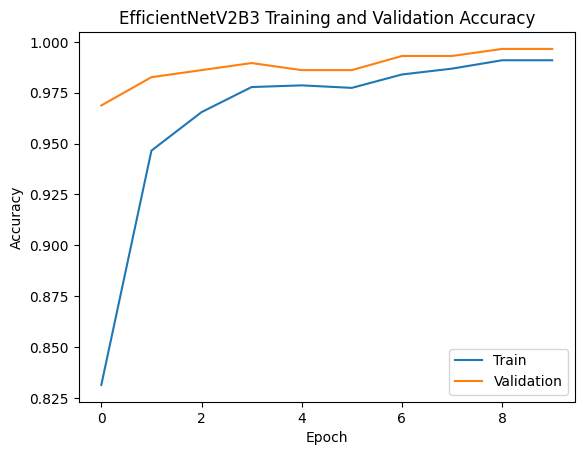

In [39]:
# Plot training and validation accuracy
plt.plot(history_3.history['accuracy'], label='Train')
plt.plot(history_3.history['val_accuracy'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('EfficientNetV2B3 Training and Validation Accuracy')
plt.show()

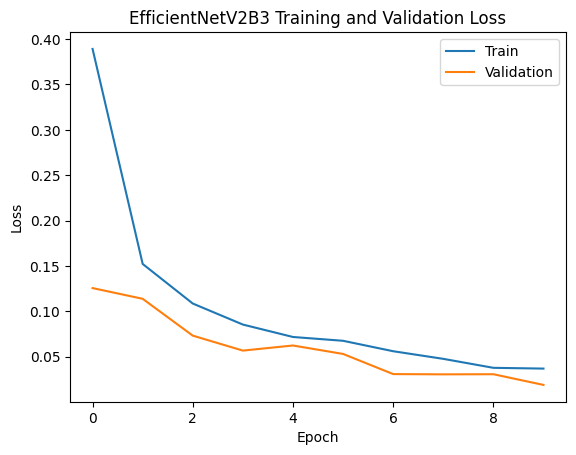

In [40]:
# Plot training and validation accuracy
plt.plot(history_3.history['loss'], label='Train')
plt.plot(history_3.history['val_loss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('EfficientNetV2B3 Training and Validation Loss')
plt.show()

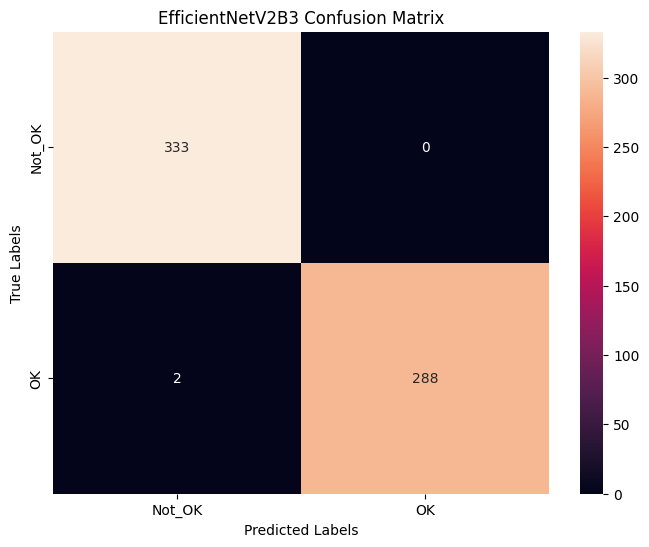

In [41]:
# Get the predicted labels for the test set
predicted_labels = []
true_labels = []

for images, labels in testing_ds:
    true_labels.extend(labels.numpy())
    predictions = model.predict(images, verbose=0)
    predicted_labels.extend((predictions > 0.5).astype(int).flatten())

# Create a confusion matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels)

# Plot the confusion matrix using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('EfficientNetV2B3 Confusion Matrix')
plt.show()

In [42]:
model.save(f"Models/EfficientNetV2B3_V2")

INFO:tensorflow:Assets written to: Models/EfficientNetV2B3_V2\assets


INFO:tensorflow:Assets written to: Models/EfficientNetV2B3_V2\assets


## Testing

In [3]:
model = models.load_model("Models/EfficientNetV2B3_V2")

In [4]:
import cv2
import matplotlib.pyplot as plt

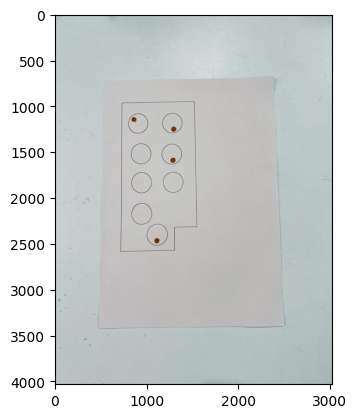

In [17]:
# test_img = cv2.imread('IMG_5935.jpg')
test_img = cv2.imread('IMG_5985.jpg')
plt.imshow(test_img)

In [18]:
test_img = cv2.resize(test_img,(iz,iz))
test_input = test_img.reshape((1,iz,iz,3))

In [19]:
threshold = 0.5
predictions = model.predict(test_input)
binary_predictions = (predictions > threshold).astype(int)
binary_predictions

1/1 [==============================] - 0s 38ms/step


array([[0]])